<a href="https://colab.research.google.com/github/aabyyaann/scikit-learn-Cookbook/blob/main/Chapter12_Cross_Validation_and_Model_Evaluation_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 12 - Cross-Validation and Model Evaluation Techniques

Notebook ini membahas teknik evaluasi model pada machine learning menggunakan **scikit-learn**.  
Fokus utama chapter ini adalah memahami bagaimana menilai performa model secara lebih adil dan stabil melalui:

- Train-test split
- Cross-validation
- K-Fold dan Stratified K-Fold
- Grid Search untuk hyperparameter tuning
- Learning curve
- Validation curve
- Evaluasi generalisasi model

Pada notebook ini, contoh utama menggunakan dataset **Breast Cancer Wisconsin** dari scikit-learn.

## 1. Tujuan Pembelajaran

Setelah menyelesaikan chapter ini, kita diharapkan mampu:

1. Memahami mengapa satu kali train-test split kadang tidak cukup untuk mengevaluasi model.
2. Menggunakan **cross-validation** untuk mendapatkan estimasi performa yang lebih stabil.
3. Menerapkan **KFold** dan **StratifiedKFold**.
4. Menggunakan **GridSearchCV** untuk mencari hyperparameter terbaik.
5. Memahami hubungan antara kompleksitas model, bias, variance, dan generalisasi.
6. Membaca **learning curve** dan **validation curve** untuk menganalisis perilaku model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    StratifiedKFold,
    GridSearchCV,
    learning_curve,
    validation_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

sns.set_style("whitegrid")
print("Library berhasil di-load.")

Library berhasil di-load.


## 2. Memuat Dataset

Pada chapter ini kita menggunakan **Breast Cancer Wisconsin dataset**.  
Dataset ini merupakan dataset klasifikasi biner, dengan target:

- **0** = malignant
- **1** = benign

Dataset ini cukup populer karena:
- ukurannya tidak terlalu besar,
- cocok untuk demonstrasi klasifikasi,
- memiliki fitur numerik yang cukup banyak,
- sering dipakai untuk evaluasi model.

In [2]:
cancer = load_breast_cancer()

X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name="target")

print("Ukuran dataset:", X.shape)
print("\n5 data pertama:")
display(X.head())

print("\nDistribusi target:")
print(y.value_counts())
print("\nNama target:", cancer.target_names)

Ukuran dataset: (569, 30)

5 data pertama:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Distribusi target:
target
1    357
0    212
Name: count, dtype: int64

Nama target: ['malignant' 'benign']


In [3]:
df = X.copy()
df["target"] = y

print("Info dataset:")
display(df.info())

print("\nStatistik ringkas:")
display(df.describe().T.head(10))

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness e

None


Statistik ringkas:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


## 3. Train-Test Split sebagai Baseline

Langkah evaluasi paling sederhana adalah membagi data menjadi:
- **training set** untuk melatih model
- **test set** untuk mengukur performa pada data yang tidak pernah dilihat model

Namun, train-test split hanya memakai **satu pembagian data**, sehingga hasil evaluasi bisa berubah jika pembagian datanya berubah.  
Karena itu, pada chapter ini kita akan melihat bagaimana **cross-validation** memberikan estimasi yang lebih stabil.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("Distribusi y_train:")
print(y_train.value_counts())
print("\nDistribusi y_test:")
print(y_test.value_counts())

Ukuran X_train: (455, 30)
Ukuran X_test : (114, 30)
Distribusi y_train:
target
1    285
0    170
Name: count, dtype: int64

Distribusi y_test:
target
1    72
0    42
Name: count, dtype: int64


## 4. Baseline Model: Logistic Regression

Kita mulai dengan model sederhana yaitu **Logistic Regression**.  
Karena dataset memiliki fitur numerik dengan skala yang berbeda, kita gunakan **StandardScaler** di dalam pipeline.

In [5]:
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000))
])

pipe_lr.fit(X_train, y_train)
pred_test = pipe_lr.predict(X_test)
proba_test = pipe_lr.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, pred_test)
auc = roc_auc_score(y_test, proba_test)

print("Baseline Logistic Regression")
print("Test Accuracy :", round(acc, 4))
print("Test ROC AUC  :", round(auc, 4))

Baseline Logistic Regression
Test Accuracy : 0.9825
Test ROC AUC  : 0.9954


Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



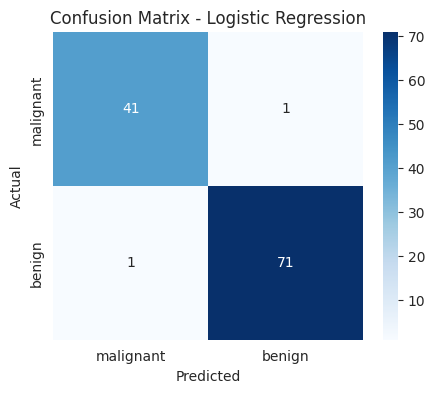

In [6]:
print("Classification Report:")
print(classification_report(y_test, pred_test, target_names=cancer.target_names))

cm = confusion_matrix(y_test, pred_test)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## 5. Mengapa Cross-Validation Dibutuhkan?

Satu kali train-test split memiliki kelemahan:
1. Hasil bisa bergantung pada pembagian data tertentu.
2. Jika test set terlalu mudah atau terlalu sulit, hasil evaluasi menjadi bias.
3. Kita tidak tahu apakah performa model konsisten pada pembagian data lain.

**Cross-validation** mengatasi masalah ini dengan membagi data menjadi beberapa fold, lalu model dilatih dan diuji berkali-kali pada kombinasi data yang berbeda.

## 6. Cross-Validation Dasar dengan cross_val_score

Pada **k-fold cross-validation**, data dibagi menjadi k bagian (fold).  
Setiap iterasi:
- 1 fold dipakai sebagai validation set
- sisa fold dipakai untuk training

Lalu skor dari semua fold dirata-ratakan.

In [7]:
cv_scores = cross_val_score(
    pipe_lr,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", np.round(cv_scores, 4))
print("Mean CV accuracy       :", round(cv_scores.mean(), 4))
print("Std CV accuracy        :", round(cv_scores.std(), 4))

Cross-validation scores: [0.9825 0.9825 0.9737 0.9737 0.9912]
Mean CV accuracy       : 0.9807
Std CV accuracy        : 0.0065


### Interpretasi Hasil Cross-Validation

Dari hasil di atas, kita memperoleh:
- skor accuracy pada masing-masing fold,
- rata-rata performa model,
- dan simpangan baku (standar deviasi) untuk melihat kestabilan model.

Semakin kecil variasi skor antar fold, biasanya semakin stabil model tersebut.

,Fold,Accuracy
0,1,0.982456
1,2,0.982456
2,3,0.973684
3,4,0.973684
4,5,0.991150


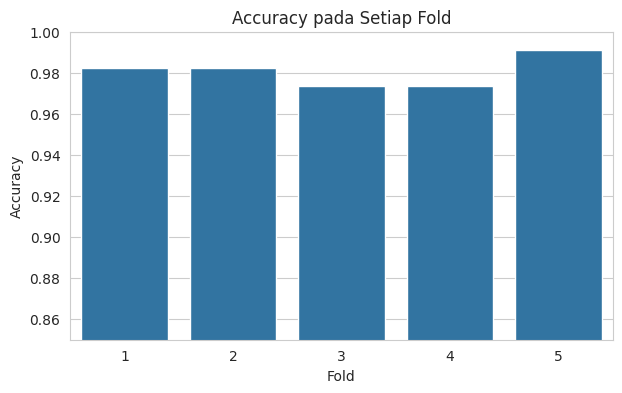

In [8]:
cv_results_df = pd.DataFrame({
    "Fold": np.arange(1, len(cv_scores) + 1),
    "Accuracy": cv_scores
})

display(cv_results_df)

plt.figure(figsize=(7, 4))
sns.barplot(data=cv_results_df, x="Fold", y="Accuracy")
plt.ylim(0.85, 1.0)
plt.title("Accuracy pada Setiap Fold")
plt.show()

## 7. KFold Cross-Validation

Secara default, untuk klasifikasi, scikit-learn biasanya memakai pembagian yang mempertimbangkan distribusi kelas.  
Namun, kita juga bisa mendefinisikan skema pembagian sendiri dengan **KFold**.

KFold membagi data menjadi beberapa fold tanpa secara eksplisit menjaga proporsi label di tiap fold.

In [9]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

scores_kfold = cross_val_score(
    pipe_lr,
    X,
    y,
    cv=kfold,
    scoring="accuracy"
)

print("KFold scores:", np.round(scores_kfold, 4))
print("Mean KFold accuracy:", round(scores_kfold.mean(), 4))
print("Std KFold accuracy :", round(scores_kfold.std(), 4))

KFold scores: [0.9737 0.9825 0.9649 0.9912 0.9735]
Mean KFold accuracy: 0.9771
Std KFold accuracy : 0.009


## 8. StratifiedKFold

Untuk masalah klasifikasi, biasanya lebih aman menggunakan **StratifiedKFold**.  
Metode ini menjaga proporsi kelas pada setiap fold agar tetap mirip dengan proporsi kelas pada dataset asli.

Hal ini penting terutama jika dataset tidak seimbang.

In [10]:
strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_strat = cross_val_score(
    pipe_lr,
    X,
    y,
    cv=strat_kfold,
    scoring="accuracy"
)

print("StratifiedKFold scores:", np.round(scores_strat, 4))
print("Mean StratifiedKFold accuracy:", round(scores_strat.mean(), 4))
print("Std StratifiedKFold accuracy :", round(scores_strat.std(), 4))

StratifiedKFold scores: [0.9737 0.9474 0.9649 0.9912 0.9912]
Mean StratifiedKFold accuracy: 0.9737
Std StratifiedKFold accuracy : 0.0166


,Method,Score
0,Simple Train-Test,0.982456
1,5-Fold CV,0.980686
2,KFold,0.977146
3,StratifiedKFold,0.973669


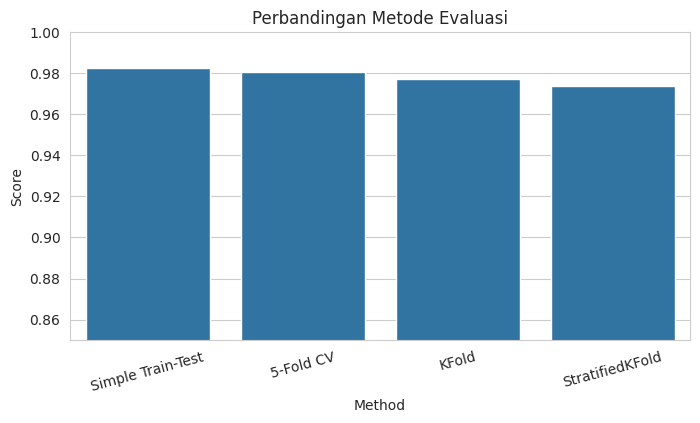

In [11]:
comparison_cv = pd.DataFrame({
    "Method": ["Simple Train-Test", "5-Fold CV", "KFold", "StratifiedKFold"],
    "Score": [
        acc,
        cv_scores.mean(),
        scores_kfold.mean(),
        scores_strat.mean()
    ]
})

display(comparison_cv)

plt.figure(figsize=(8, 4))
sns.barplot(data=comparison_cv, x="Method", y="Score")
plt.ylim(0.85, 1.0)
plt.title("Perbandingan Metode Evaluasi")
plt.xticks(rotation=15)
plt.show()

## 9. Evaluasi Model dengan Metrik Lain

Selain accuracy, pada klasifikasi biner kita sering memakai **ROC AUC**.  
ROC AUC mengukur kemampuan model membedakan dua kelas pada berbagai threshold.

Semakin mendekati 1, semakin baik model membedakan kelas positif dan negatif.

In [12]:
cv_auc = cross_val_score(
    pipe_lr,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("ROC AUC per fold:", np.round(cv_auc, 4))
print("Mean ROC AUC    :", round(cv_auc.mean(), 4))
print("Std ROC AUC     :", round(cv_auc.std(), 4))

ROC AUC per fold: [0.9948 0.9967 0.997  0.9878 0.9997]
Mean ROC AUC    : 0.9952
Std ROC AUC     : 0.004


## 10. Support Vector Machine sebagai Model Kedua

Agar evaluasi lebih menarik, kita bandingkan Logistic Regression dengan **Support Vector Machine (SVM)**.  
SVM cukup sensitif terhadap hyperparameter seperti:
- **C**: mengontrol regularisasi
- **gamma**: mengontrol pengaruh titik data pada kernel RBF

In [13]:
pipe_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=True))
])

svc_scores = cross_val_score(
    pipe_svc,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("SVC 5-fold accuracy:", np.round(svc_scores, 4))
print("Mean accuracy      :", round(svc_scores.mean(), 4))
print("Std accuracy       :", round(svc_scores.std(), 4))

SVC 5-fold accuracy: [0.9737 0.9561 1.     0.9649 0.9735]
Mean accuracy      : 0.9736
Std accuracy       : 0.0147


In [14]:
model_compare = pd.DataFrame({
    "Model": ["Logistic Regression", "SVC"],
    "Mean CV Accuracy": [cv_scores.mean(), svc_scores.mean()],
    "Std CV Accuracy": [cv_scores.std(), svc_scores.std()]
})

display(model_compare)

,Model,Mean CV Accuracy,Std CV Accuracy
0,Logistic Regression,0.980686,0.006539
1,SVC,0.973638,0.014679


## 11. Hyperparameter Tuning dengan GridSearchCV

Cross-validation tidak hanya dipakai untuk evaluasi, tetapi juga untuk **pemilihan hyperparameter**.  
Salah satu cara paling umum adalah **GridSearchCV**.

Pada Grid Search:
1. kita menentukan daftar kombinasi hyperparameter,
2. model dilatih dan divalidasi untuk setiap kombinasi,
3. kombinasi dengan skor terbaik dipilih sebagai model terbaik.

### Hyperparameter yang akan diuji pada SVC

Kita akan mencari kombinasi terbaik untuk:
- `svc__C`
- `svc__gamma`

Karena model dibungkus dalam pipeline, nama hyperparameter harus ditulis dengan format:

`nama_step__nama_parameter`

In [15]:
param_grid = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": [0.001, 0.01, 0.1, 1]
}

grid = GridSearchCV(
    pipe_svc,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score  :", round(grid.best_score_, 4))
print("Test score     :", round(grid.score(X_test, y_test), 4))

Best parameters: {'svc__C': 10, 'svc__gamma': 0.01}
Best CV score  : 0.9802
Test score     : 0.9825


In [16]:
results = pd.DataFrame(grid.cv_results_)
selected_cols = [
    "param_svc__C",
    "param_svc__gamma",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]
results = results[selected_cols].sort_values("rank_test_score")

display(results.head(10))

,param_svc__C,param_svc__gamma,mean_test_score,std_test_score,rank_test_score
9,10.0,0.010,0.980220,0.016150,1
12,100.0,0.001,0.978022,0.015541,2
8,10.0,0.001,0.973626,0.014906,3
5,1.0,0.010,0.969231,0.023466,4
13,100.0,0.010,0.969231,0.016150,4
6,1.0,0.100,0.960440,0.016447,6
10,10.0,0.100,0.951648,0.021534,7
4,1.0,0.001,0.947253,0.018906,8
14,100.0,0.100,0.947253,0.024474,8
2,0.1,0.100,0.945055,0.013900,10


## 12. Interpretasi Hasil Grid Search

Dari hasil Grid Search, kita bisa melihat:
- kombinasi parameter terbaik,
- rata-rata skor cross-validation,
- variasi performa antar fold,
- ranking setiap kombinasi parameter.

Ini jauh lebih informatif daripada hanya mencoba satu kombinasi parameter secara manual.

In [17]:
best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)
best_proba = best_model.predict_proba(X_test)[:, 1]

print("Evaluasi model terbaik hasil Grid Search")
print("Accuracy :", round(accuracy_score(y_test, best_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, best_proba), 4))
print("\nClassification Report:")
print(classification_report(y_test, best_pred, target_names=cancer.target_names))

Evaluasi model terbaik hasil Grid Search
Accuracy : 0.9825
ROC AUC  : 0.9977

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



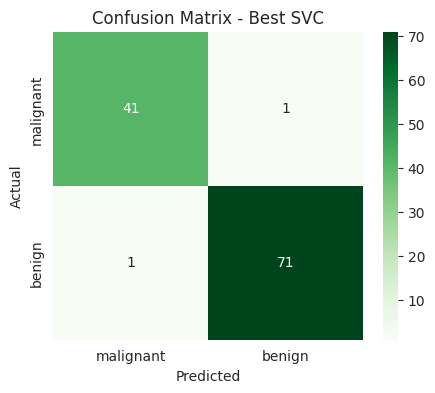

In [18]:
cm_best = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Greens",
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Best SVC")
plt.show()

## 13. Learning Curve

**Learning curve** digunakan untuk melihat bagaimana performa model berubah ketika jumlah data training bertambah.

Biasanya kita memplot:
- **training score**
- **validation score**

Learning curve sangat berguna untuk menganalisis:
- overfitting
- underfitting
- apakah model butuh lebih banyak data

In [19]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_model,
    X=X,
    y=y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

learning_df = pd.DataFrame({
    "Train Size": train_sizes,
    "Train Score Mean": train_mean,
    "Validation Score Mean": test_mean
})

display(learning_df)

,Train Size,Train Score Mean,Validation Score Mean
0,45,1.000000,0.803059
1,147,0.983673,0.956047
2,250,0.984800,0.968390
3,352,0.986364,0.977177
4,455,0.988132,0.978932


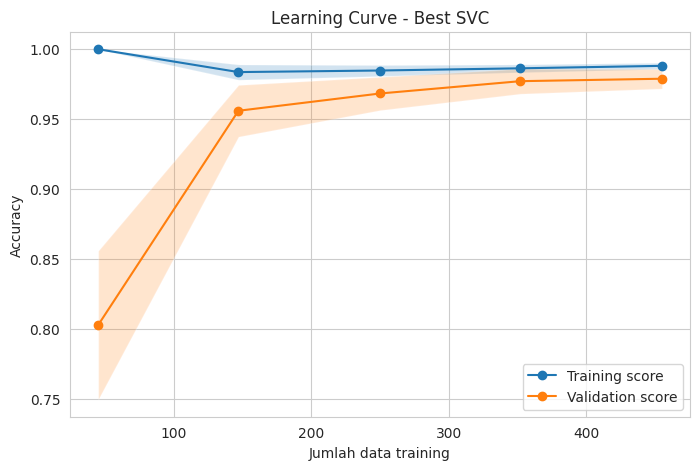

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training score")
plt.plot(train_sizes, test_mean, marker="o", label="Validation score")

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2)

plt.xlabel("Jumlah data training")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Best SVC")
plt.legend()
plt.show()

### Interpretasi Learning Curve

Beberapa pola umum:
1. **Training tinggi, validation rendah** → indikasi overfitting
2. **Keduanya rendah** → indikasi underfitting
3. **Keduanya tinggi dan dekat** → generalisasi baik

Learning curve membantu kita memutuskan apakah:
- model terlalu kompleks,
- model terlalu sederhana,
- atau kita membutuhkan lebih banyak data.

## 14. Validation Curve

Jika learning curve menunjukkan pengaruh jumlah data, maka **validation curve** menunjukkan pengaruh **nilai hyperparameter** terhadap performa model.

Di sini kita akan memvariasikan parameter **C** pada SVC dan melihat:
- training score
- validation score

In [21]:
param_range = [0.01, 0.1, 1, 10, 100, 1000]

train_scores_v, test_scores_v = validation_curve(
    Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(gamma=grid.best_params_["svc__gamma"]))
    ]),
    X,
    y,
    param_name="svc__C",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_mean_v = train_scores_v.mean(axis=1)
train_std_v = train_scores_v.std(axis=1)
test_mean_v = test_scores_v.mean(axis=1)
test_std_v = test_scores_v.std(axis=1)

validation_df = pd.DataFrame({
    "C": param_range,
    "Train Score Mean": train_mean_v,
    "Validation Score Mean": test_mean_v
})

display(validation_df)

,C,Train Score Mean,Validation Score Mean
0,0.01,0.627417,0.627418
1,0.10,0.952110,0.950815
2,1.00,0.978468,0.968390
3,10.00,0.988139,0.978932
4,100.00,0.994289,0.968374
5,1000.00,1.000000,0.964866


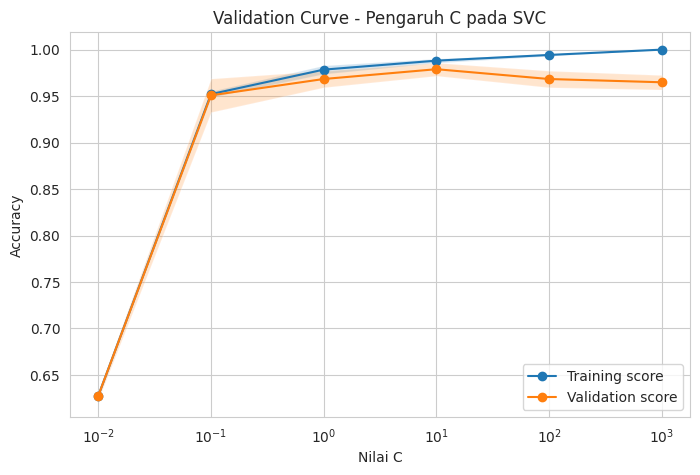

In [22]:
plt.figure(figsize=(8, 5))
plt.semilogx(param_range, train_mean_v, marker="o", label="Training score")
plt.semilogx(param_range, test_mean_v, marker="o", label="Validation score")

plt.fill_between(param_range, train_mean_v - train_std_v, train_mean_v + train_std_v, alpha=0.2)
plt.fill_between(param_range, test_mean_v - test_std_v, test_mean_v + test_std_v, alpha=0.2)

plt.xlabel("Nilai C")
plt.ylabel("Accuracy")
plt.title("Validation Curve - Pengaruh C pada SVC")
plt.legend()
plt.show()

## 15. Analisis Overfitting dan Underfitting dari Validation Curve

Secara umum:
- **C terlalu kecil** → regularisasi terlalu kuat → model terlalu sederhana → underfitting
- **C terlalu besar** → model sangat fleksibel → berpotensi overfitting
- nilai **C optimal** biasanya berada pada area ketika validation score mencapai titik terbaik

## 16. Perbandingan Beberapa Model dengan Cross-Validation

Sekarang kita bandingkan beberapa model sekaligus:
- Logistic Regression
- SVC
- SVC hasil tuning

Tujuannya adalah melihat bahwa evaluasi model sebaiknya dilakukan secara konsisten menggunakan prosedur yang sama.

In [23]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=5000))
    ]),
    "SVC Default": Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC())
    ]),
    "SVC Tuned": best_model
}

rows = []
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    rows.append({
        "Model": name,
        "Mean CV Accuracy": scores.mean(),
        "Std CV Accuracy": scores.std()
    })

comparison_models = pd.DataFrame(rows).sort_values("Mean CV Accuracy", ascending=False)
display(comparison_models)

,Model,Mean CV Accuracy,Std CV Accuracy
0,Logistic Regression,0.980686,0.006539
2,SVC Tuned,0.978932,0.006990
1,SVC Default,0.973638,0.014679


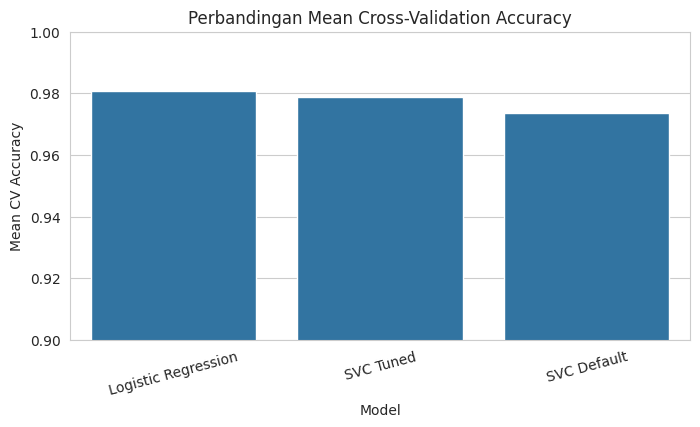

In [24]:
plt.figure(figsize=(8, 4))
sns.barplot(data=comparison_models, x="Model", y="Mean CV Accuracy")
plt.ylim(0.9, 1.0)
plt.title("Perbandingan Mean Cross-Validation Accuracy")
plt.xticks(rotation=15)
plt.show()

## 17. Practical Exercise 1 — Cross-validating a Logistic Regression Model

Pada latihan ini, kita fokus pada Logistic Regression dan melihat bagaimana skor model berubah ketika jumlah fold diubah.

In [25]:
fold_settings = [3, 5, 10]
exercise_rows = []

for k in fold_settings:
    scores = cross_val_score(
        Pipeline([
            ("scaler", StandardScaler()),
            ("logreg", LogisticRegression(max_iter=5000))
        ]),
        X,
        y,
        cv=k,
        scoring="accuracy"
    )

    exercise_rows.append({
        "CV Folds": k,
        "Mean Accuracy": scores.mean(),
        "Std Accuracy": scores.std()
    })

exercise1_df = pd.DataFrame(exercise_rows)
display(exercise1_df)

,CV Folds,Mean Accuracy,Std Accuracy
0,3,0.975392,0.002515
1,5,0.980686,0.006539
2,10,0.980670,0.014570


## 18. Practical Exercise 2 — Hyperparameter Tuning with Grid Search

Latihan kedua adalah melakukan pencarian parameter pada Logistic Regression.  
Kita akan mencoba beberapa nilai **C** dan membandingkan performanya.

In [26]:
pipe_lr_grid = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000))
])

param_grid_lr = {
    "logreg__C": [0.01, 0.1, 1, 10, 100]
}

grid_lr = GridSearchCV(
    pipe_lr_grid,
    param_grid_lr,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best parameter Logistic Regression:", grid_lr.best_params_)
print("Best CV score                    :", round(grid_lr.best_score_, 4))
print("Test score                       :", round(grid_lr.score(X_test, y_test), 4))

Best parameter Logistic Regression: {'logreg__C': 0.1}
Best CV score                    : 0.9802
Test score                       : 0.9737


In [27]:
lr_results = pd.DataFrame(grid_lr.cv_results_)
lr_results = lr_results[[
    "param_logreg__C",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

display(lr_results)

,param_logreg__C,mean_test_score,std_test_score,rank_test_score
1,0.10,0.980220,0.016150,1
2,1.00,0.980220,0.012815,1
3,10.00,0.969231,0.016150,3
4,100.00,0.956044,0.019658,4
0,0.01,0.951648,0.020382,5


## 19. Practical Exercise 3 — Assessing Generalization with Learning and Validation Curves

Pada latihan terakhir, kita simpulkan pembelajaran chapter ini:
- **Learning curve** dipakai untuk melihat pengaruh ukuran data training
- **Validation curve** dipakai untuk melihat pengaruh hyperparameter
- Keduanya membantu kita memahami **generalisasi model**

In [28]:
summary_df = pd.DataFrame({
    "Konsep": [
        "Train-Test Split",
        "Cross-Validation",
        "KFold / StratifiedKFold",
        "GridSearchCV",
        "Learning Curve",
        "Validation Curve"
    ],
    "Fungsi": [
        "Membagi data train dan test untuk evaluasi awal",
        "Mengukur performa model pada beberapa fold",
        "Mengatur cara pembagian fold",
        "Mencari hyperparameter terbaik secara sistematis",
        "Menganalisis pengaruh jumlah data training",
        "Menganalisis pengaruh nilai hyperparameter"
    ]
})

display(summary_df)

,Konsep,Fungsi
0,Train-Test Split,Membagi data train dan test untuk evaluasi awal
1,Cross-Validation,Mengukur performa model pada beberapa fold
2,KFold / StratifiedKFold,Mengatur cara pembagian fold
3,GridSearchCV,Mencari hyperparameter terbaik secara sistematis
4,Learning Curve,Menganalisis pengaruh jumlah data training
5,Validation Curve,Menganalisis pengaruh nilai hyperparameter


## 20. Kesimpulan Chapter 12

Pada chapter ini, kita mempelajari bahwa evaluasi model tidak cukup hanya dengan satu kali train-test split.  
Dengan **cross-validation**, kita bisa memperoleh estimasi performa yang lebih stabil dan lebih representatif terhadap kemampuan generalisasi model.

Poin penting dari chapter ini:
1. **Cross-validation** membantu mengurangi bias dari satu pembagian data.
2. **StratifiedKFold** sangat berguna untuk klasifikasi karena menjaga distribusi kelas.
3. **GridSearchCV** memungkinkan pencarian hyperparameter terbaik secara sistematis.
4. **Learning curve** membantu menganalisis apakah model membutuhkan lebih banyak data atau justru terlalu kompleks.
5. **Validation curve** membantu memahami pengaruh hyperparameter terhadap overfitting dan underfitting.
6. Evaluasi model yang baik harus mempertimbangkan **akurasi, stabilitas, dan generalisasi**.

Secara keseluruhan, chapter ini menunjukkan bahwa model machine learning yang baik bukan hanya model dengan skor tinggi pada training set, tetapi model yang mampu mempertahankan performa pada data baru yang belum pernah dilihat sebelumnya.

## 21. Ringkasan Singkat Chapter 12

Ringkasan isi chapter:
- memuat dataset klasifikasi
- membuat baseline Logistic Regression
- mengevaluasi model dengan train-test split
- melakukan cross-validation
- membandingkan KFold dan StratifiedKFold
- mengevaluasi metrik accuracy dan ROC AUC
- melakukan hyperparameter tuning menggunakan GridSearchCV
- menganalisis learning curve dan validation curve
- membandingkan beberapa model untuk melihat generalisasi terbaik

In [29]:
print("Notebook Chapter 12 selesai dijalankan.")
print("Topik utama: Cross-Validation and Model Evaluation Techniques")

Notebook Chapter 12 selesai dijalankan.
Topik utama: Cross-Validation and Model Evaluation Techniques
